<a href="https://colab.research.google.com/github/broistg/ML-Assignment-DNAC1/blob/main/notebooks/BTL3_deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0.&nbsp;User manual

This Google Colab file implements a deep learning pipeline for an image dataset (Fruit Recognition). To run this notebook, do the following:
1. First click the Colab `Run all` button (library installation and dataset loading are automated).
2. Select the confiuration you want in the last cell (default: Finetuning ResNet50).
3. After that click `Run Pipeline` in the last cell. The pipeline will run according to your configuration.

If you want to rerun the pipeline with another configuration, you need to rerun the last cell and then repeat from step 2.

# 1.&nbsp;Prepare the necessary data and libraries

## 1.1.&nbsp;Verify and install necessary libraries

In [ ]:
import sys
import subprocess
import os
import math
import random
import time
import json
from pathlib import Path
from PIL import Image
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
from torch.amp import autocast, GradScaler
from torch.utils.data import DataLoader, Dataset
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torchvision.models as models
import timm
import kagglehub

import ipywidgets as widgets
from IPython.display import display, clear_output

def pip_install(packages):
    """Installs packages quietly."""
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet"] + packages)

pip_install(["scikit-learn", "pandas", "matplotlib", "seaborn", "torch", "torchvision", "tqdm"])

In [ ]:
RND = 42
np.random.seed(RND)
random.seed(RND)
torch.manual_seed(RND)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RND)

Using device: cuda


## 1.2.&nbsp;Download and store the dataset

In [ ]:
data_path = kagglehub.dataset_download("utkarshsaxenadn/fruits-classification")
data_path = data_path + "/Fruits Classification"
print("Path to dataset:", data_path)

Using Colab cache for faster access to the 'fruits-classification' dataset.
Path to dataset: /kaggle/input/fruits-classification/Fruits Classification


## 1.3.&nbsp;Load Dataset

In [ ]:
class FruitDataset(Dataset):
    """
    Custom dataset that:
    - Treats only top-level folder names as class names
    - Recursively collects all images in nested subfolders
    """
    def __init__(self, img_paths, labels, transform=None):
        self.img_paths = img_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label

def get_fruit_datasets(root_path):
    """
    root_path: the directory containing 'train', 'valid', 'test' subfolders.
    Each of those subfolders should contain class folders (e.g., Apple, Banana)
    which in turn contain image files.
    """
    root_path = Path(root_path)

    # ------------ 1. Discover class names from the 'train' split ------------
    train_split_path = root_path / 'train'
    if not train_split_path.is_dir():
        raise FileNotFoundError(f"'{train_split_path}' not found. Please ensure 'train' folder exists under '{root_path}'.")

    class_dirs = sorted([d for d in train_split_path.iterdir() if d.is_dir()])
    CLASS_NAMES = [d.name for d in class_dirs]

    if not CLASS_NAMES:
        raise ValueError(f"No class folders found in '{train_split_path}'.")

    print("Detected classes:", CLASS_NAMES)

    # ------------ 2. Helper function to collect images for a specific split ------------
    def _collect_images_for_split(split_name, class_names_list):
        split_path = root_path / split_name
        if not split_path.is_dir():
            print(f"Warning: '{split_path}' not found. Returning empty dataset for {split_name}.")
            return np.array([]), np.array([])

        img_paths = []
        labels = []
        for class_id, class_name in enumerate(class_names_list):
            class_folder_path = split_path / class_name
            if not class_folder_path.is_dir():
                print(f"Warning: Class folder '{class_folder_path}' not found for split '{split_name}'. Skipping.")
                continue

            # Recursively gather all images within the class folder
            for dirpath, _, filenames in os.walk(class_folder_path):
                for fname in filenames:
                    if fname.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".webp")):
                        img_paths.append(os.path.join(dirpath, fname))
                        labels.append(class_id)
        return np.array(img_paths), np.array(labels)

    # ------------ 3. Collect ALL images from original train, valid, and test splits ------------
    all_img_paths = []
    all_labels = []

    # Collect from 'train'
    train_img_paths_orig, train_labels_orig = _collect_images_for_split('train', CLASS_NAMES)
    all_img_paths.extend(train_img_paths_orig)
    all_labels.extend(train_labels_orig)

    # Collect from 'valid'
    val_img_paths_orig, val_labels_orig = _collect_images_for_split('valid', CLASS_NAMES)
    all_img_paths.extend(val_img_paths_orig)
    all_labels.extend(val_labels_orig)

    # Collect from 'test'
    test_img_paths_orig, test_labels_orig = _collect_images_for_split('test', CLASS_NAMES)
    all_img_paths.extend(test_img_paths_orig)
    all_labels.extend(test_labels_orig)

    all_img_paths = np.array(all_img_paths)
    all_labels = np.array(all_labels)

    print(f"Total images collected from all original splits: {len(all_img_paths)}")
    print("Performing 80/10/10 train/validation/test split with stratification...")

    # ------------ 4. Split the combined dataset into new train (80%), val (10%), test (10%) ------------
    # First split: 80% train, 20% temp (for val and test)
    train_img_paths, temp_img_paths, train_labels, temp_labels = train_test_split(
        all_img_paths, all_labels, test_size=0.2, stratify=all_labels, random_state=RND
    )

    # Second split: 10% val, 10% test from the 20% temp
    val_img_paths, test_img_paths, val_labels, test_labels = train_test_split(
        temp_img_paths, temp_labels, test_size=0.5, stratify=temp_labels, random_state=RND
    )

    # ------------ 5. Create new dataset objects for the custom splits ------------
    transform_raw = transforms.Compose([transforms.ToTensor()])
    train_set = FruitDataset(train_img_paths, train_labels, transform_raw)
    val_set   = FruitDataset(val_img_paths, val_labels, transform_raw)
    test_set  = FruitDataset(test_img_paths, test_labels, transform_raw)

    print(f"New train set size: {len(train_set)}")
    print(f"New validation set size: {len(val_set)}")
    print(f"New test set size: {len(test_set)}")

    return train_set, val_set, test_set, CLASS_NAMES

train_set, val_set, test_set, CLASS_NAMES = get_fruit_datasets(data_path)

sample_img, _ = train_set[0]
print(f"Sample Image shape: {sample_img.shape}, Image dtype: {sample_img.dtype}")
print(f"Train: {len(train_set)}, Val: {len(val_set)}, Test: {len(test_set)}")

Detected classes: ['Apple', 'Banana', 'Grape', 'Mango', 'Strawberry']
Total images collected from all original splits: 10000
Performing 80/10/10 train/validation/test split with stratification...
New train set size: 8000
New validation set size: 1000
New test set size: 1000
Sample Image shape: torch.Size([3, 174, 290]), Image dtype: torch.float32
Train: 8000, Val: 1000, Test: 1000


# 2.&nbsp;Exploratory Data Analysis (EDA)

--- TRAIN ---


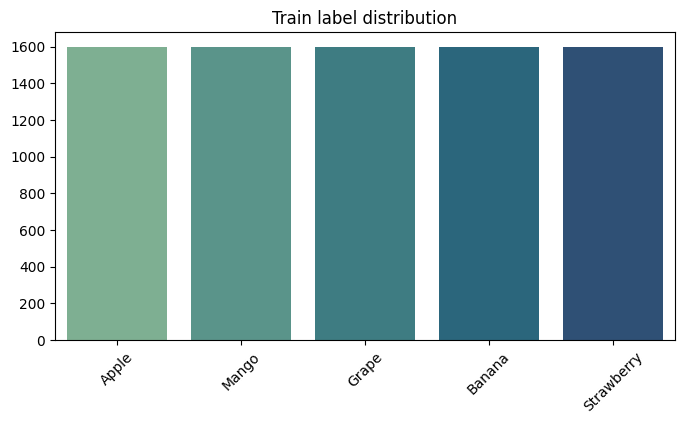

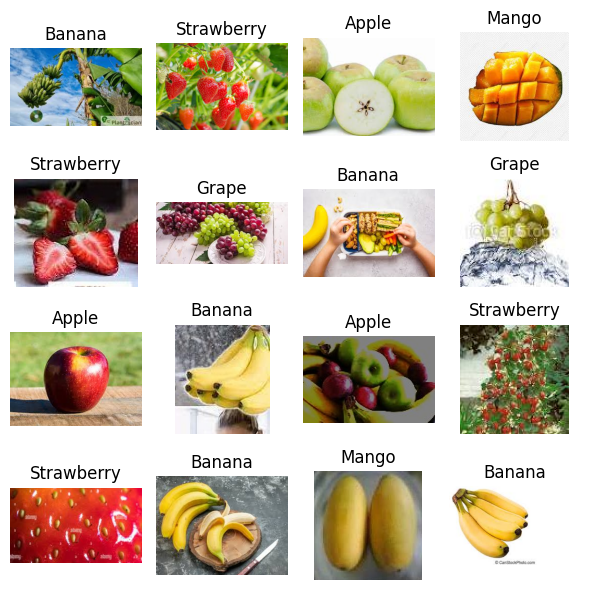

--- VAL ---


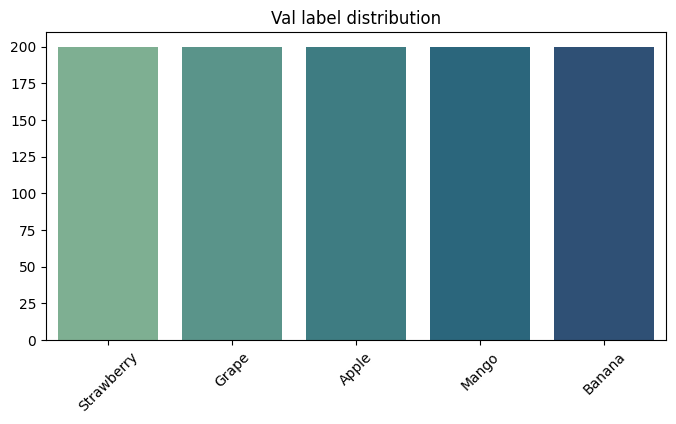

--- TEST ---


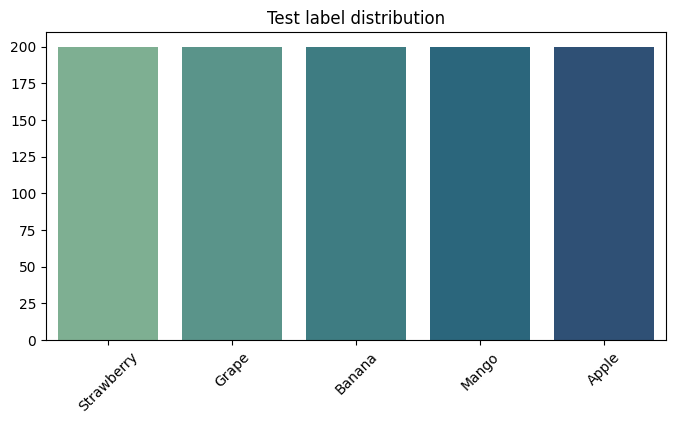

In [ ]:
def show_label_distribution(dataset, title='Label distribution'):
    labels = dataset.labels.tolist()
    counter = Counter(labels)
    sorted_items = sorted(counter.items(), key=lambda item: item[1], reverse=True)
    xs = [ CLASS_NAMES[item[0]] for item in sorted_items]
    ys = [ item[1] for item in sorted_items]
    plt.figure(figsize=(8,4))
    sns.barplot(x=xs, y=ys, hue=xs, palette="crest", legend=False)
    plt.title(title)
    plt.xticks(rotation=45)
    plt.show()

def show_sample_grid(dataset, n=16, resize=None):
    fig, axes = plt.subplots(int(math.sqrt(n)), int(math.sqrt(n)), figsize=(6,6))
    axes = axes.flatten()
    rng = np.random.default_rng(seed=RND)
    idxs = rng.choice(len(dataset), size=n, replace=False)
    for ax, i in zip(axes, idxs):
        img, label = dataset[i]
        if isinstance(img, torch.Tensor):
            img = transforms.ToPILImage()(img)
        if resize is not None:
            img = img.resize((resize, resize))
        ax.imshow(np.asarray(img))
        ax.set_title(CLASS_NAMES[label])
        ax.axis('off')
    plt.tight_layout()
    plt.show()

def eda_report(train_set, val_set, test_set):
    print('--- TRAIN ---')
    show_label_distribution(train_set, 'Train label distribution')
    show_sample_grid(train_set, n=16)
    print('--- VAL ---')
    show_label_distribution(val_set, 'Val label distribution')
    print('--- TEST ---')
    show_label_distribution(test_set, 'Test label distribution')

# Run a quick EDA by default
eda_report(train_set, val_set, test_set)

# 2.&nbsp;Data preprocessing

In [ ]:
def preprocessing(CONFIG, train_set_raw, val_set_raw, test_set_raw):
    transform_train = transforms.Compose([
        transforms.Resize((CONFIG['resize'], CONFIG['resize'])),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.25),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    transform_val_test = transforms.Compose([
        transforms.Resize((CONFIG['resize'], CONFIG['resize'])),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Apply transformations to the raw FruitDataset instances
    train_set_transformed = FruitDataset(train_set_raw.img_paths, train_set_raw.labels, transform=transform_train)
    val_set_transformed = FruitDataset(val_set_raw.img_paths, val_set_raw.labels, transform=transform_val_test)
    test_set_transformed = FruitDataset(test_set_raw.img_paths, test_set_raw.labels, transform=transform_val_test)

    num_workers = CONFIG['num_workers']
    train_loader = DataLoader(
        dataset=train_set_transformed,
        batch_size=CONFIG['batch_size'],
        shuffle=True,
        num_workers=num_workers, pin_memory=True, persistent_workers=True
    )
    val_loader = DataLoader(
        dataset=val_set_transformed,
        batch_size=CONFIG['batch_size'],
        shuffle=False,
        num_workers=num_workers, pin_memory=True, persistent_workers=True
    )
    test_loader = DataLoader(
        dataset=test_set_transformed,
        batch_size=CONFIG['batch_size'],
        shuffle=False,
        num_workers=num_workers, pin_memory=True, persistent_workers=True
    )

    return train_loader, val_loader, test_loader

# 3.&nbsp;Helper Functions for Training and Evaluation

Helper: Train and Validate one Epoch

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    running_loss = 0
    correct = 0

    for images, labels in tqdm(loader, desc="Train", leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()

        with autocast(DEVICE.type):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()

    return running_loss / len(loader.dataset), correct / len(loader.dataset)


@torch.no_grad()
def eval_one_epoch(model, loader, criterion):
    model.eval()
    running_loss = 0
    correct = 0

    for images, labels in tqdm(loader, desc="Val/Test", leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        with autocast(DEVICE.type):
            outputs = model(images)
            loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()

    return running_loss / len(loader.dataset), correct / len(loader.dataset)

Helper: Early Stopping Logic

In [ ]:
class EarlyStopping:
    def __init__(self, path, patience=3, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.min_delta:
            # No significant improvement
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            # Improvement found
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

Helper: Separate Head and Backbone params

In [ ]:
def get_model_params_groups(model):
    head_names = ['head', 'fc', 'classifier']
    found_head = None

    # 1. Detect the head attribute name
    for name in head_names:
        if hasattr(model, name):
            found_head = name
            break
    if not found_head:
        raise ValueError(f"Could not find classifier head. Model has keys: {list(model.state_dict().keys())[:5]}")

    # 2. Separate Parameters
    head_params = []
    backbone_params = []
    for name, param in model.named_parameters():
        if name.startswith(found_head):
            head_params.append(param)
        else:
            backbone_params.append(param)
    return head_params, backbone_params, found_head

# 4.&nbsp;Main Training and Testing Loop

In [ ]:
def train_and_test(CONFIG, train_set, val_set, test_set, save_file, comparison=False):
    freeze_epochs, finetune_epochs, warmup_epochs = CONFIG['freeze_epochs'], CONFIG['finetune_epochs'], CONFIG['warmup_epochs']
    patience, min_delta = CONFIG['patience'], CONFIG['min_delta']

    train_loader, val_loader, test_loader = preprocessing(CONFIG, train_set, val_set, test_set)
    model = timm.create_model(CONFIG['model_name'], pretrained=True, num_classes=len(CLASS_NAMES))
    model = model.to(DEVICE)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    scaler = GradScaler(DEVICE.type)

    # ------------------ FREEZE PHASE ------------------
    start_time_train = time.time()
    print("Stage 1: Frozen backbone training")
    head_params, backbone_params, head_name = get_model_params_groups(model)
    for param in backbone_params:
        param.requires_grad = False
    for param in head_params:
        param.requires_grad = True

    optimizer_s1 = optim.AdamW(head_params, lr=CONFIG['freeze_lr'])
    for epoch in range(freeze_epochs):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer_s1, scaler)
        val_loss, val_acc = eval_one_epoch(model, val_loader, criterion)

        print(f"[Epoch {epoch+1}/{freeze_epochs}] Train Loss: {tr_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # ------------------ FINETUNE PHASE ------------------
    print("Stage 2: Full fine-tuning")
    for param in model.parameters():
        param.requires_grad = True

    head_params, backbone_params, _ = get_model_params_groups(model)
    # EfficientNet specific optimizer: RMSprop
    if CONFIG['model_name'] == 'efficientnet_b0':
        optimizer_s2 = optim.RMSprop(
            [
                {'params': backbone_params, 'lr': CONFIG['backbone_lr']},
                {'params': head_params, 'lr': CONFIG['head_lr']}
            ],
            alpha=0.9,
            eps=1e-3,
            weight_decay=1e-5,
            momentum=0.9
        )
    else: # For other models, use AdamW
        optimizer_s2 = optim.AdamW([
            {'params': backbone_params, 'lr': CONFIG['backbone_lr']}, # Slow learning for backbone
            {'params': head_params,     'lr': CONFIG['head_lr']}      # Fast learning for head
        ], weight_decay=0.01)

    scheduler_warmup = LinearLR(optimizer_s2, start_factor=0.01, total_iters=warmup_epochs)
    scheduler_cosine = CosineAnnealingLR(optimizer_s2, T_max=finetune_epochs - warmup_epochs, eta_min=1e-6)
    scheduler_s2 = SequentialLR(
        optimizer_s2,
        schedulers=[scheduler_warmup, scheduler_cosine],
        milestones=[warmup_epochs]
    )
    early_stopper = EarlyStopping(save_file, patience=patience, min_delta=min_delta)

    for epoch in range(finetune_epochs):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer_s2, scaler)
        val_loss, val_acc = eval_one_epoch(model, val_loader, criterion)

        scheduler_s2.step()

        print(f"[Epoch {epoch+1}/{finetune_epochs}] Train Loss: {tr_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        early_stopper(val_loss, model) # Also handle saving best model

        if early_stopper.early_stop:
            print("Early stopping triggered! Training stopped.")
            break

    end_time_train = time.time()
    training_time = end_time_train - start_time_train

    # ------------------ TEST ------------------
    print("Loading best model for testing...")
    model.load_state_dict(torch.load(save_file))
    model.eval()
    y_true_test, y_pred_test = [], []

    start_time_inference = time.time()
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            outputs = outputs.view(outputs.size(0), -1)
            labels = labels.view(-1)
            _, predicted = outputs.max(1)

            y_true_test.extend(labels.cpu().numpy())
            y_pred_test.extend(predicted.cpu().numpy())
    end_time_inference = time.time()
    inference_time = end_time_inference - start_time_inference

    accuracy = accuracy_score(y_true_test, y_pred_test)
    precision = precision_score(y_true_test, y_pred_test, average='macro', zero_division=0)
    recall = recall_score(y_true_test, y_pred_test, average='macro', zero_division=0)
    f1 = f1_score(y_true_test, y_pred_test, average='macro', zero_division=0)

    if not comparison:
        print("=== Test Metrics ===")
        print(f"Accuracy : {accuracy*100:.2f}%")
        print(f"Precision: {precision*100:.2f}%")
        print(f"Recall   : {recall*100:.2f}%")
        print(f"F1-score : {f1*100:.2f}%")
        print(f"Training Time: {training_time:.2f} seconds")
        print(f"Inference Time: {inference_time:.2f} seconds")
        print("\nDetailed classification report:")
        print(classification_report(y_true_test, y_pred_test))

        cm = confusion_matrix(y_true_test, y_pred_test)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap='Blues', values_format='d')
        plt.title("Confusion Matrix")
        plt.show()
        return
    else:
        # No need to print all details for comparison mode, just return the metrics
        print(f"Final Test Accuracy: {accuracy:.4f}")
        print(f"Final Test Precision: {precision:.4f}")
        print(f"Final Test Recall: {recall:.4f}")
        print(f"Final Test F1: {f1:.4f}")

        return {
            'model_name': CONFIG['model_name'],
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'training_time': training_time,
            'inference_time': inference_time
        }


In [ ]:
def display_comparison_results(comparison_results):
    results_df = pd.DataFrame(comparison_results)
    results_df_styled = results_df.set_index('model_name').style.format({
        'accuracy': '{:.2%}',
        'precision': '{:.2%}',
        'recall': '{:.2%}',
        'f1': '{:.2%}',
        'training_time': '{:.2f}s',
        'inference_time': '{:.2f}s'
    })
    print("\n--- Comparison Results Table ---")
    display(results_df_styled)

    # Prepare data for plotting
    metrics = ['accuracy', 'precision', 'recall', 'f1', 'training_time', 'inference_time']
    metric_titles = {
        'accuracy': 'Accuracy',
        'precision': 'Precision',
        'recall': 'Recall',
        'f1': 'F1-score',
        'training_time': 'Training Time (s)',
        'inference_time': 'Inference Time (s)'
    }

    # Plotting bar charts for each metric
    print("\n--- Comparison Results Visualizations ---")
    fig, axes = plt.subplots(2, 3, figsize=(24, 12)) # Changed to 2 rows, 3 columns
    axes = axes.flatten()

    for i, metric in enumerate(metrics):
        sns.barplot(x='model_name', y=metric, data=results_df, ax=axes[i], hue='model_name',
                    legend=False, palette='viridis')
        axes[i].set_title(f'{metric_titles[metric]} Comparison')
        axes[i].set_xlabel('Model')
        axes[i].set_ylabel(metric_titles[metric])

        # Set y-axis limit for performance metrics (0 to 1), let time metrics auto-scale
        if metric in ['accuracy', 'precision', 'recall', 'f1']:
            axes[i].set_ylim(0, 1)
            for container in axes[i].containers:
                axes[i].bar_label(container, fmt='%.2%')
        else:
            axes[i].set_ylim(bottom=0)
            for container in axes[i].containers:
                axes[i].bar_label(container, fmt='%.2f')

        axes[i].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()


# 5.&nbsp;Configuration

In [ ]:
DEFAULT_MODEL_CONFIGS = {
    "VGG16": {
        "model_name": "vgg16_bn",
        "batch_size": 32,
        "freeze_lr": 1e-3,
        "backbone_lr": 1e-5,
        "head_lr": 1e-4
    },

    "ResNet50": {
        "model_name": "resnet50",
        "batch_size": 64,
        "freeze_lr": 1e-3,
        "backbone_lr": 5e-5,
        "head_lr": 1e-3
    },

    "EfficientNet-B0": {
        "model_name": "efficientnet_b0",
        "batch_size": 64,
        "freeze_lr": 1e-3,
        "backbone_lr": 5e-5,
        "head_lr": 1e-3,
    },

    "ViT": {
        "model_name": "vit_base_patch16_224",
        "batch_size": 16,
        "freeze_lr": 1e-3,
        "backbone_lr": 1e-5,
        "head_lr": 5e-4,
    },

    "SwinTransformer": {
        "model_name": "swin_tiny_patch4_window7_224",
        "batch_size": 16,
        "freeze_lr": 1e-3,
        "backbone_lr": 2e-5,
        "head_lr": 5e-4,
    }
}

# Controls
style = {'description_width': 'initial'}
mode_widget = widgets.ToggleButtons(options=['Single Model', 'Comparison'], value='Single Model', description='Mode:', style=style)
model_widget = widgets.Dropdown(options=DEFAULT_MODEL_CONFIGS.keys(), value='ResNet50', description='Model:', style=style)
resize_widget = widgets.IntSlider(value=224, min=32, max=512, step=8, description='Resize:', style=style)
batch_widget = widgets.IntSlider(
    value=DEFAULT_MODEL_CONFIGS[model_widget.value]['batch_size'],
    min=1,
    max=256,
    step=1,
    description='Batch size:', style=style
)

s1_lr_widget = widgets.FloatSlider(
    value=DEFAULT_MODEL_CONFIGS[model_widget.value]['freeze_lr'],
    min=1e-6,
    max=1e-2,
    step=1e-5,
    description='Freeze LR:',
    readout_format=".5f", style=style
)

bb_lr_widget = widgets.FloatSlider(
    value=DEFAULT_MODEL_CONFIGS[model_widget.value]['backbone_lr'],
    min=1e-6,
    max=1e-2,
    step=1e-5,
    description='Backbone LR:',
    readout_format=".5f", style=style
)

head_lr_widget = widgets.FloatSlider(
    value=DEFAULT_MODEL_CONFIGS[model_widget.value]['head_lr'],
    min=1e-6,
    max=1e-2,
    step=1e-5,
    description='Head LR:',
    readout_format=".5f", style=style
)

freeze_epochs_widget = widgets.IntSlider(
    value=3,
    min=0,
    max=10,
    step=1,
    description='Freeze epochs:', style=style
)

epoch_widget = widgets.IntSlider(
    value=20,
    min=1,
    max=30,
    step=1,
    description='Finetune epochs:', style=style
)

run_button = widgets.Button(description='Run pipeline', button_style='success')
output = widgets.Output()

# dynamic hyperparams
def update_hyperparams(change=None):
    model = model_widget.value
    if model in DEFAULT_MODEL_CONFIGS.keys():
        batch_widget.value = DEFAULT_MODEL_CONFIGS[model]['batch_size']
        s1_lr_widget.value = DEFAULT_MODEL_CONFIGS[model_widget.value]['freeze_lr']
        bb_lr_widget.value = DEFAULT_MODEL_CONFIGS[model_widget.value]['backbone_lr']
        head_lr_widget.value = DEFAULT_MODEL_CONFIGS[model_widget.value]['head_lr']
model_widget.observe(update_hyperparams, names='value')
update_hyperparams()

# config box visibility based on mode
config_box = widgets.VBox([])
def update_config_box(change=None):
    if mode_widget.value == 'Single Model':
        config_box.children = [model_widget, resize_widget, batch_widget, s1_lr_widget, bb_lr_widget, head_lr_widget, freeze_epochs_widget, epoch_widget, run_button]
    elif mode_widget.value == 'Comparison':
        config_box.children = [freeze_epochs_widget, epoch_widget, run_button]
mode_widget.observe(update_config_box, names='value')
update_config_box()

CONFIG = {}
# Run button handler
def on_run_clicked(b):
    with output:
        output.clear_output(wait=True)
    if mode_widget.value == 'Comparison':
        if os.path.exists('comparison_results.json'):
            with open('comparison_results.json', 'r') as f:
                comparison_results = json.load(f)
            print("Loaded saved results.")
        else:
            print("--- Starting Comparison Mode Training ---")
            comparison_results = []
            for model_key in DEFAULT_MODEL_CONFIGS.keys():
                current_config = {
                    'model_name': DEFAULT_MODEL_CONFIGS[model_key]['model_name'],
                    'resize': 224,
                    'batch_size': DEFAULT_MODEL_CONFIGS[model_key]['batch_size'],
                    'freeze_lr': DEFAULT_MODEL_CONFIGS[model_key]['freeze_lr'],
                    'backbone_lr': DEFAULT_MODEL_CONFIGS[model_key]['backbone_lr'],
                    'head_lr': DEFAULT_MODEL_CONFIGS[model_key]['head_lr'],
                    'freeze_epochs': freeze_epochs_widget.value,
                    'finetune_epochs': epoch_widget.value,
                    'warmup_epochs': 3,
                    'num_workers': 2,
                    'patience': 4,
                    'min_delta': 0.001
                }
                print(f"\n--- Training and evaluating {model_key} ---")
                save_file = f"{model_key}_best.pth"
                metrics = train_and_test(current_config, train_set, val_set, test_set, save_file, comparison=True)
                comparison_results.append(metrics)

            with open('comparison_results.json', 'w') as f:
                json.dump(comparison_results, f)
            print("--- Comparison Training Complete. Displaying Results ---")

        display_comparison_results(comparison_results)
    else:
        print("--- Starting Single Model Training ---")
        model_key = model_widget.value
        current_config = {
            'model_name': DEFAULT_MODEL_CONFIGS[model_key]['model_name'],
            'resize': resize_widget.value,
            'batch_size': batch_widget.value,
            'freeze_lr': s1_lr_widget.value,
            'backbone_lr': bb_lr_widget.value,
            'head_lr': head_lr_widget.value,
            'freeze_epochs': freeze_epochs_widget.value,
            'finetune_epochs': epoch_widget.value,
            "warmup_epochs": 3,
            'num_workers': 2,
            'patience': 4,
            'min_delta': 0.001
        }
        save_file = f"{model_key}_best.pth"
        train_and_test(current_config, train_set, val_set, test_set, save_file, comparison=False)
        print("--- Single Model Training Complete. ---")


run_button.on_click(on_run_clicked)

ui = widgets.VBox([mode_widget, config_box, output])

# 6.&nbsp;Config UI and Run

--- Starting Comparison Mode Training ---

--- Training and evaluating VGG16 ---


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/554M [00:00<?, ?B/s]

Stage 1: Frozen backbone training


Train:   0%|          | 0/250 [00:00<?, ?it/s]

...

Train:   0%|          | 0/500 [00:00<?, ?it/s]

Val/Test:   0%|          | 0/63 [00:00<?, ?it/s]

[Epoch 12/30] Train Loss: 0.4023, Val Loss: 0.4706, Val Acc: 0.9610
EarlyStopping counter: 4 out of 4
Early stopping triggered! Training stopped.
Loading best model for testing...
Final Test Accuracy: 0.9540
Final Test Precision: 0.9539
Final Test Recall: 0.9540
Final Test F1: 0.9539
--- Comparison Training Complete. Displaying Results ---

--- Comparison Results Table ---


,accuracy,precision,recall,f1,training_time,inference_time
model_name,,,,,,
vgg16_bn,94.00%,93.99%,94.00%,93.99%,2189.44s,5.71s
resnet50,93.70%,93.71%,93.70%,93.66%,1531.96s,3.72s
efficientnet_b0,94.50%,94.49%,94.50%,94.49%,1268.44s,2.93s
vit_base_patch16_224,95.70%,95.73%,95.70%,95.69%,1382.45s,11.08s
swin_tiny_patch4_window7_224,95.40%,95.39%,95.40%,95.39%,924.15s,4.75s



--- Comparison Results Visualizations ---


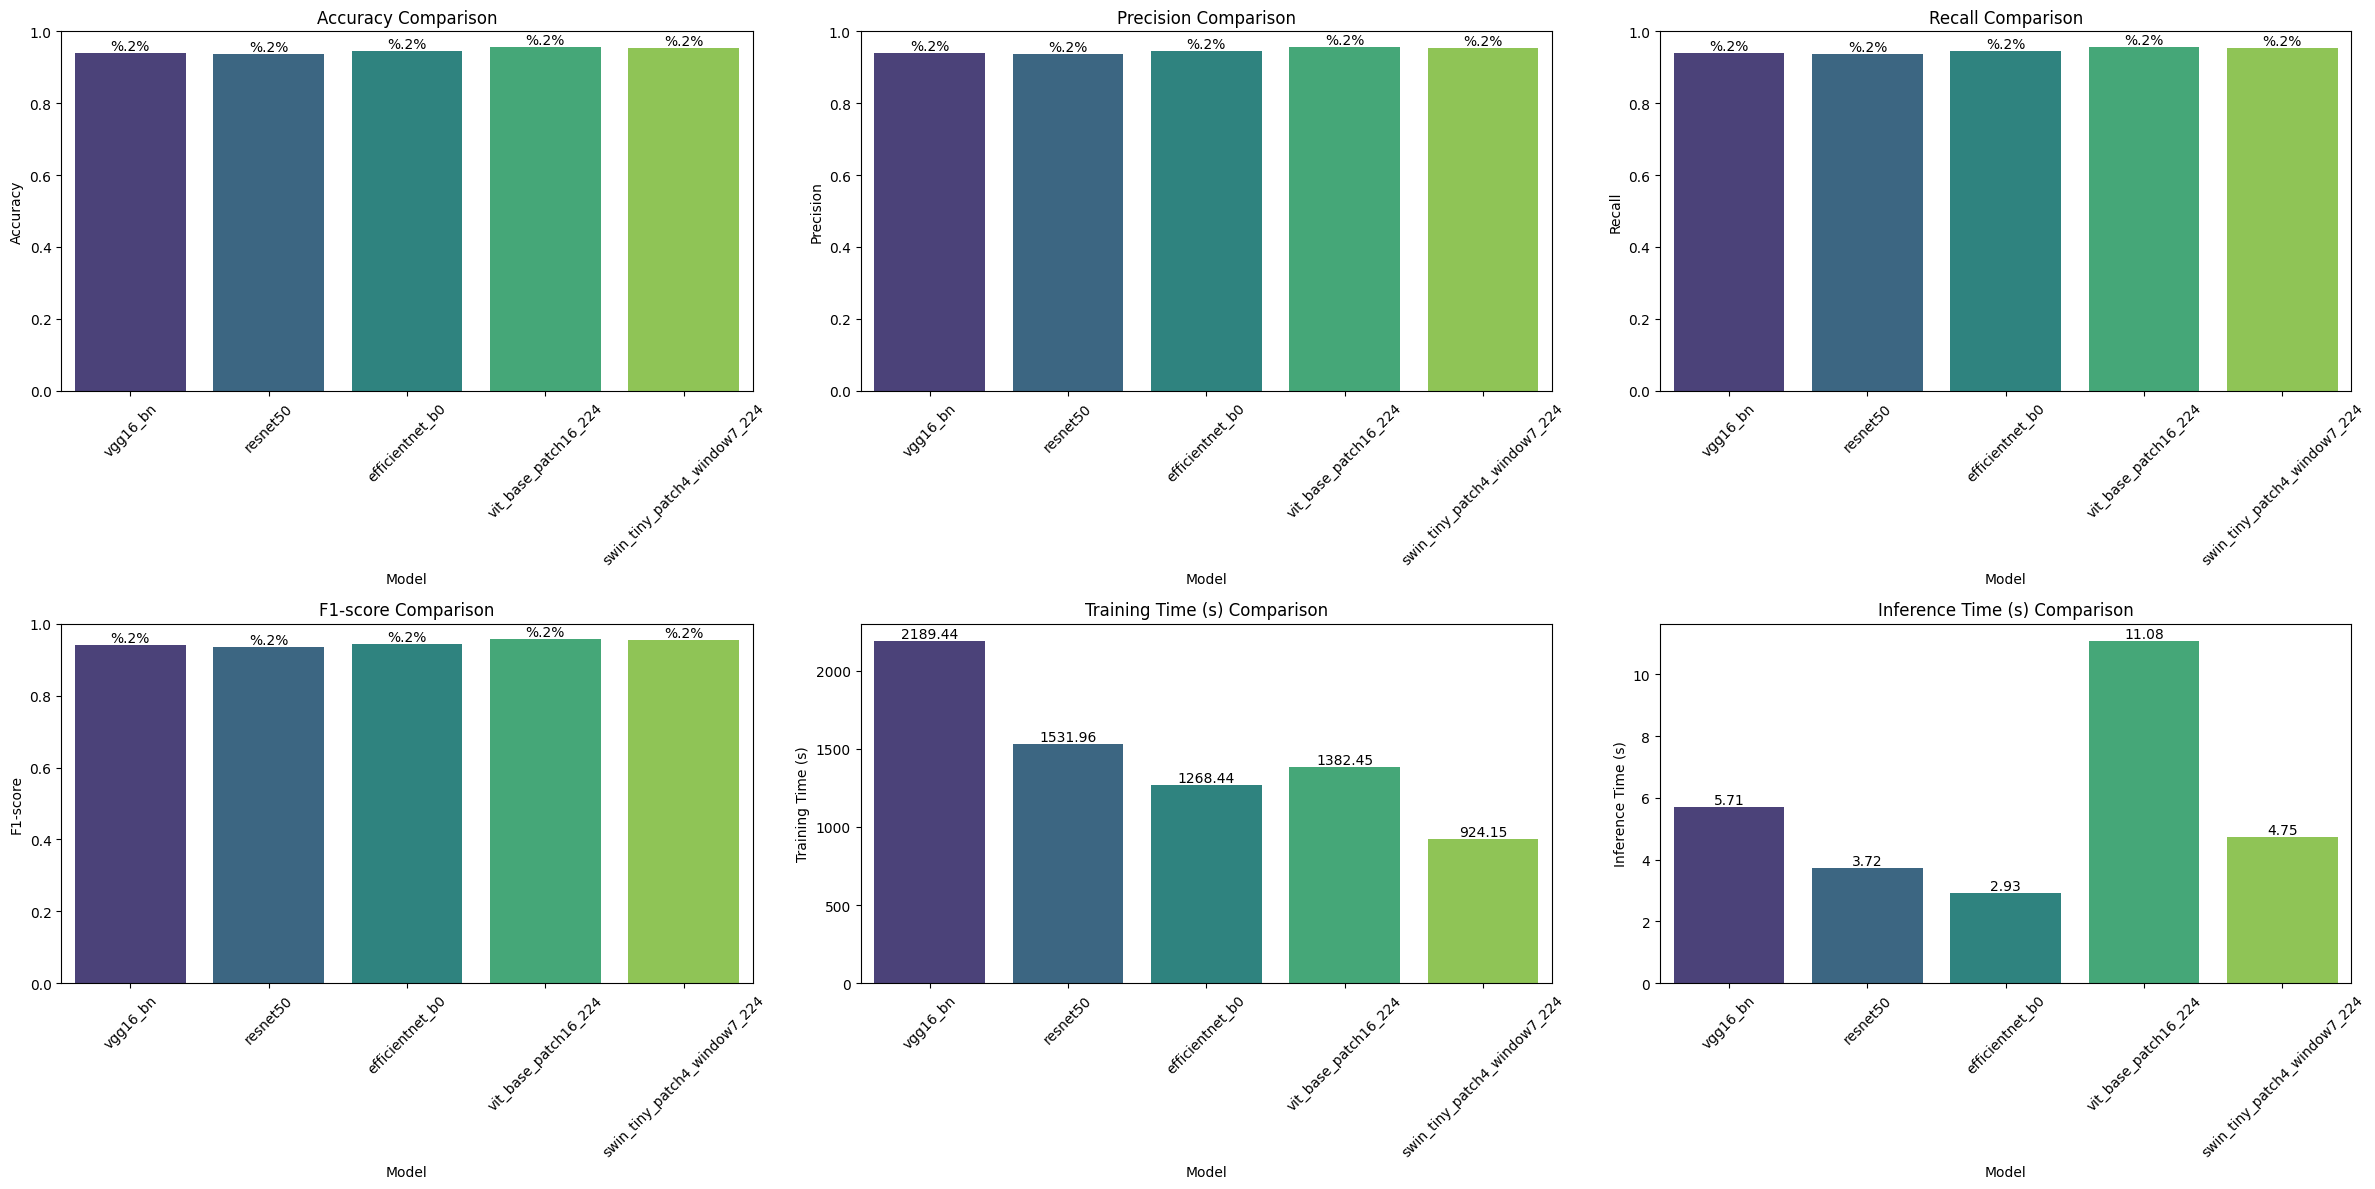

In [ ]:
display(ui)